# 🎬 What Actually Makes a Movie Succeed?

**CMSC 320 — Introduction to Data Science | Spring 2026**  
**Instructor:** Dr. Fardina Alam  
**Checkpoint 2 — Data Preprocessing & Exploratory Data Analysis**

---

### Group Members & Contributions

| Name | Sections |
|------|----------|
| *Dheebhan Jeganathan* | 1, 2, 3 |
| *Esha Vigneswaran* | 4, 5, 6 |

## 1. Introduction

**Dataset source:** Banik, R. (2017). *The Movies Dataset*. Kaggle. https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

In [1]:
# installs for necessary libraries

!pip install pandas numpy scipy matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importing necessary libraries

import pandas as pd
import numpy as np
import ast
import warnings

from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ignoring warnings for cleaner displays
warnings.filterwarnings('ignore')

# pandas formatting for better data display
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)

# plot default settings for better aesthetics
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titleweight'] = 'bold'

print('All libraries loaded successfully!')

All libraries loaded successfully!


---

## 2. Data Curation

### 2a. Loading and Displaying the Raw Data

In [3]:
# loading metadata dataset
df = pd.read_csv('movies_metadata.csv', low_memory=False)

# basic shape info + columns names
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nColumn names:\n{list(df.columns)}')

Shape: 45,466 rows × 24 columns

Column names:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']


In [4]:
df.head(3) # example data points w/ column values

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,"373,554,033.00",81.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.70,"5,415.00"
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,"262,797,249.00",104.00,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.90,"2,413.00"
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.00,101.00,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.50,92.00


In [5]:
# calculating null value ratio per row to decide suitable testing methods
info_df = pd.DataFrame({
    'dtype'    : df.dtypes,
    'non_null' : df.notnull().sum(),
    'null_pct' : (df.isnull().mean() * 100).round(1)
})
print(info_df.to_string())

                         dtype  non_null  null_pct
adult                      str     45466      0.00
belongs_to_collection      str      4494     90.10
budget                     str     45466      0.00
genres                     str     45466      0.00
homepage                   str      7782     82.90
id                         str     45466      0.00
imdb_id                    str     45449      0.00
original_language          str     45455      0.00
original_title             str     45466      0.00
overview                   str     44512      2.10
popularity                 str     45461      0.00
poster_path                str     45080      0.80
production_companies       str     45463      0.00
production_countries       str     45463      0.00
release_date               str     45379      0.20
revenue                float64     45460      0.00
runtime                float64     45203      0.60
spoken_languages           str     45460      0.00
status                     str 

## 3. Cleaning + Preprocessing Data for EDA

##### Based on the null percentages calculated in the previous part, we decided to do fill in the values for the runtime category. We chose this because the other values with large null percentages seem too tied to a specific movie and would be hard to gauge based on other data.

In [ ]:
import ast

# INFLATION DATA SOURCE — U.S. Bureau of Labor Statistics (BLS)
# Historical data (1913–2024): https://www.bls.gov/cpi/tables/supplemental-files/historical-cpi-u-202312.xlsx
# BLS CPI home page:           https://www.bls.gov/cpi/
# We retrieved 2025-2026 data based on "projected" values from the same website 
# for a constant standard of comparison

# How we implemented it:
#   Adjusted Amount = Nominal Amount × (CPI in Target Year / CPI in Release Year)
#   e.g. $1M in 1980 (CPI=82.4) → $1M × (326.0 / 82.4) ≈ $3.96M in 2026 dollars

CPI_BY_YEAR = {
    1913: 9.9,   1914: 10.0,  1915: 10.1,  1916: 10.9,  1917: 12.8,
    1918: 15.1,  1919: 17.3,  1920: 20.0,  1921: 17.9,  1922: 16.8,
    1923: 17.1,  1924: 17.1,  1925: 17.5,  1926: 17.7,  1927: 17.4,
    1928: 17.1,  1929: 17.1,  1930: 16.7,  1931: 15.2,  1932: 13.7,
    1933: 13.0,  1934: 13.4,  1935: 13.7,  1936: 13.9,  1937: 14.4,
    1938: 14.1,  1939: 13.9,  1940: 14.0,  1941: 14.7,  1942: 16.3,
    1943: 17.3,  1944: 17.6,  1945: 18.0,  1946: 19.5,  1947: 22.3,
    1948: 24.1,  1949: 23.8,  1950: 24.1,  1951: 26.0,  1952: 26.5,
    1953: 26.7,  1954: 26.9,  1955: 26.8,  1956: 27.2,  1957: 28.1,
    1958: 28.9,  1959: 29.1,  1960: 29.6,  1961: 29.9,  1962: 30.2,
    1963: 30.6,  1964: 31.0,  1965: 31.5,  1966: 32.4,  1967: 33.4,
    1968: 34.8,  1969: 36.7,  1970: 38.8,  1971: 40.5,  1972: 41.8,
    1973: 44.4,  1974: 49.3,  1975: 53.8,  1976: 56.9,  1977: 60.6,
    1978: 65.2,  1979: 72.6,  1980: 82.4,  1981: 90.9,  1982: 96.5,
    1983: 99.6,  1984: 103.9, 1985: 107.6, 1986: 109.6, 1987: 113.6,
    1988: 118.3, 1989: 124.0, 1990: 130.7, 1991: 136.2, 1992: 140.3,
    1993: 144.5, 1994: 148.2, 1995: 152.4, 1996: 156.9, 1997: 160.5,
    1998: 163.0, 1999: 166.6, 2000: 172.2, 2001: 177.1, 2002: 179.9,
    2003: 184.0, 2004: 188.9, 2005: 195.3, 2006: 201.6, 2007: 207.3,
    2008: 215.3, 2009: 214.5, 2010: 218.1, 2011: 224.9, 2012: 229.6,
    2013: 233.0, 2014: 236.7, 2015: 237.0, 2016: 240.0, 2017: 245.1,
    2018: 251.1, 2019: 255.7, 2020: 258.8, 2021: 270.9, 2022: 292.7,
    2023: 304.7, 2024: 314.2, 2025: 320.0, 2026: 326.0,  # 2025–26 projected
}

TARGET_YEAR = 2026
CPI_TARGET  = CPI_BY_YEAR[TARGET_YEAR]

def adjust_for_inflation(amount, release_year):
    """Convert a nominal dollar amount to TARGET_YEAR (2026) dollars using CPI-U.
    Returns NaN for missing, zero, or out-of-table values."""
    if pd.isna(amount) or amount == 0:
        return float('nan')
    cpi_then = CPI_BY_YEAR.get(int(release_year)) if not pd.isna(release_year) else None
    if cpi_then is None:
        return float('nan')
    return amount * (CPI_TARGET / cpi_then)


# PARSING:
# Several TMDB columns are stored as stringified Python lists of dicts:
# e.g. genres = "[{'id': 16, 'name': 'Animation'}, {'id': 35, 'name': 'Comedy'}]"
# The functions below safely parse these and extract the names into strings

def safe_parse(val):
    """Safely convert a stringified Python list/dict back to a Python object,
    returning [] on any failure like NaN."""
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError, TypeError):
        return []

def extract_names(val):
    """Extract every 'name' field from a stringified list of dicts."""
    parsed = safe_parse(val)
    if isinstance(parsed, list):
        return [d['name'] for d in parsed if isinstance(d, dict) and 'name' in d]
    return []

def extract_first_name(val):
    """Return only the first 'name' from a stringified list of dicts,
    returning 'Unknown' if none is found"""
    names = extract_names(val)
    return names[0] if names else 'Unknown'

df['genres_list']               = df['genres'].apply(extract_names)
df['primary_genre']             = df['genres'].apply(extract_first_name)
df['production_companies_list'] = df['production_companies'].apply(extract_names)
df['production_countries_list'] = df['production_countries'].apply(extract_names)
df['spoken_languages_list']     = df['spoken_languages'].apply(extract_names)
df['num_genres']                = df['genres_list'].apply(len)
df['num_prod_companies']        = df['production_companies_list'].apply(len)

print('Parsed columns created.')
print(df[['title', 'primary_genre', 'genres_list']].head(5).to_string())

Parsed columns created.
                         title primary_genre                   genres_list
0                    Toy Story     Animation   [Animation, Comedy, Family]
1                      Jumanji     Adventure  [Adventure, Fantasy, Family]
2             Grumpier Old Men       Romance             [Romance, Comedy]
3            Waiting to Exhale        Comedy      [Comedy, Drama, Romance]
4  Father of the Bride Part II        Comedy                      [Comedy]


In [7]:
# [Runtime: Missing at Random (MAR)]
# During our EDA, we noticed that runtime has 0.6% null values (~263 rows). 
# We classify this as MAR (missing at random)) because missingness is likely related to 
# other observed variables — specifically, films from more obscure, indie developers
# or foreign markets tend to have less complete metadata on large datasets such as this.

# Because missingness correlates with genre, we decided that a global median fill would
# introduce bias. For example, filling a missing Documentary runtime with the
# overall median of ~95 mins would be inaccurate when documentaries typically
# run shorter. Instead, we use genre-median imputation each missing runtime
# is filled with the median runtime of all other films sharing the same
# primary_genre. Alongside our analysis of movies based on genre, 
# we believe that this approach preserves the natural runtime distribution 
# within each genre and produces more realistic imputations.

# Derive primary_genre inline if it doesn't exist yet
if 'primary_genre' not in df.columns:
    df['primary_genre'] = df['genres'].apply(extract_first_name)

df['runtime'] = df.groupby('primary_genre')['runtime'].transform(
    lambda x: x.fillna(x.median())
)

# Fallback for any remaining NaNs, mainly for unknown genre cases
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

print(f"Remaining runtime nulls: {df['runtime'].isna().sum()}")

Remaining runtime nulls: 0


In [8]:
# Converting numeric columns to integers/floats, coercing errors to NaN for later handling
numeric_cols = ['budget', 'revenue', 'runtime', 'vote_average',
                'vote_count', 'popularity']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Parse release date and extract useful time features
df['release_date']  = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_dow']   = df['release_date'].dt.dayofweek   # 0=Mon … 6=Sun

# Inflation-adjusted budget and revenue (2026 ($USD))
df['budget_adj']  = df.apply(
    lambda row: adjust_for_inflation(row['budget'],  row['release_year']), axis=1)
df['revenue_adj'] = df.apply(
    lambda row: adjust_for_inflation(row['revenue'], row['release_year']), axis=1)

print('Numeric parsing + inflation adjustment complete.')
df[['title', 'release_year', 'budget', 'budget_adj', 'revenue', 'revenue_adj',
    'runtime']].head()

Numeric parsing + inflation adjustment complete.


,title,release_year,budget,budget_adj,revenue,revenue_adj,runtime
0,Toy Story,"1,995.00","30,000,000.00","64,173,228.35","373,554,033.00","799,072,275.31",81.00
1,Jumanji,"1,995.00","65,000,000.00","139,041,994.75","262,797,249.00","562,151,595.63",104.00
2,Grumpier Old Men,"1,995.00",0.00,NaN,0.00,NaN,101.00
3,Waiting to Exhale,"1,995.00","16,000,000.00","34,225,721.78","81,452,156.00","174,234,926.88",127.00
4,Father of the Bride Part II,"1,995.00",0.00,NaN,"76,578,911.00","163,810,531.40",106.00


In [9]:
# clean dataset creation
df_clean = df[
    (df['budget']       >  1_000) &
    (df['revenue']      >  1_000) &
    (df['vote_count']   >= 50)    &
    (df['release_year'] >= 1980)  &
    (df['release_year'] <= 2017)
].copy()

# financial metrics derivation
df_clean['roi']         = (df_clean['revenue'] - df_clean['budget']) / df_clean['budget']
df_clean['log_revenue'] = np.log1p(df_clean['revenue'])
df_clean['log_budget']  = np.log1p(df_clean['budget'])
df_clean['profit']      = df_clean['revenue'] - df_clean['budget']

# inflation-adjusted budget and revenue columns added to clean df
df_clean['budget_adj']  = df.loc[df_clean.index, 'budget_adj']
df_clean['revenue_adj'] = df.loc[df_clean.index, 'revenue_adj']

# Binary "hit" label (we might incorporate this as part of our Checkpoint #3 solution w/ ML Linear Regressions)
df_clean['is_hit'] = (
    (df_clean['roi'] > 0) &
    (df_clean['vote_average'] >= df_clean['vote_average'].median())
).astype(int)

print(f'Clean dataset: {df_clean.shape[0]:,} movies')
print(f'Hit films:     {df_clean["is_hit"].sum():,}  '
      f'({df_clean["is_hit"].mean()*100:.1f}%)')
df_clean[['title', 'budget', 'budget_adj', 'revenue', 'revenue_adj', 'roi', 'is_hit']].head()

Clean dataset: 4,021 movies
Hit films:     1,695  (42.2%)


,title,budget,budget_adj,revenue,revenue_adj,roi,is_hit
0,Toy Story,"30,000,000.00","64,173,228.35","373,554,033.00","799,072,275.31",11.45,1
1,Jumanji,"65,000,000.00","139,041,994.75","262,797,249.00","562,151,595.63",3.04,1
5,Heat,"60,000,000.00","128,346,456.69","187,436,818.00","400,947,524.07",2.12,1
8,Sudden Death,"35,000,000.00","74,868,766.40","64,350,171.00","137,651,940.59",0.84,0
9,GoldenEye,"58,000,000.00","124,068,241.47","352,194,034.00","753,380,938.87",5.07,1


In [10]:
# summary statistics on the newly cleaned dataset
summary_cols = ['budget', 'budget_adj', 'revenue', 'revenue_adj', 'roi', 'vote_average', 'vote_count', 'runtime']
df_clean[summary_cols].describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
budget,4021.000000,39186516.586670,43197243.266031,6000.000000,11000000.000000,25000000.000000,50000000.000000,380000000.000000
budget_adj,4021.000000,66178546.014560,67253558.237946,11596.265007,19016666.666667,44616788.321168,90010040.160643,550822587.816808
revenue,4021.000000,114698571.886098,184021587.127318,1938.000000,15431177.000000,49100000.000000,132820716.000000,2787965087.000000
revenue_adj,4021.000000,196214276.280511,299656804.439897,2751.689895,28058057.163338,89789473.902557,233440128.164925,4237187031.990676
roi,4021.000000,7.506304,213.848295,-0.999790,-0.068014,1.154144,3.147276,12889.386667
vote_average,4021.000000,6.304103,0.814105,2.800000,5.800000,6.300000,6.900000,9.100000
vote_count,4021.000000,930.149217,1369.769850,50.000000,178.000000,413.000000,1048.000000,14075.000000
runtime,4021.000000,109.405123,19.879419,0.000000,96.000000,106.000000,120.000000,338.000000


---

## 4.  Statistical Analysis #1

### Does the budget put in to make the movie affect the revenue/popularity of the movie?



*   Ho = There is no correlation between budget and movie popularity (r = 0)
*   Ha = There is a correlation between budget and movie popularity (r ≠ 0)

We will use significance level α = 0.05

In [11]:
pearson_r = stats.pearsonr(df_clean['budget_adj'], df_clean['popularity'])

print("Pearson Coefficient:", pearson_r[0])
print("P-Value", pearson_r[1])

Pearson Coefficient: 0.22542743612209054
P-Value 1.6947032711211096e-47


Conclusion:

*  P is significantly less than the alpha value, meaning we can reject the null hypothesis.
*  There is a significant correlation between budget and popularity, but the Pearson coefficient is 0.258, meaning there is a weak correlation between budget and popularity.
*  We can conclude that higher budget films may slightly be more popular, but it can't singlehandedly explain popularity.

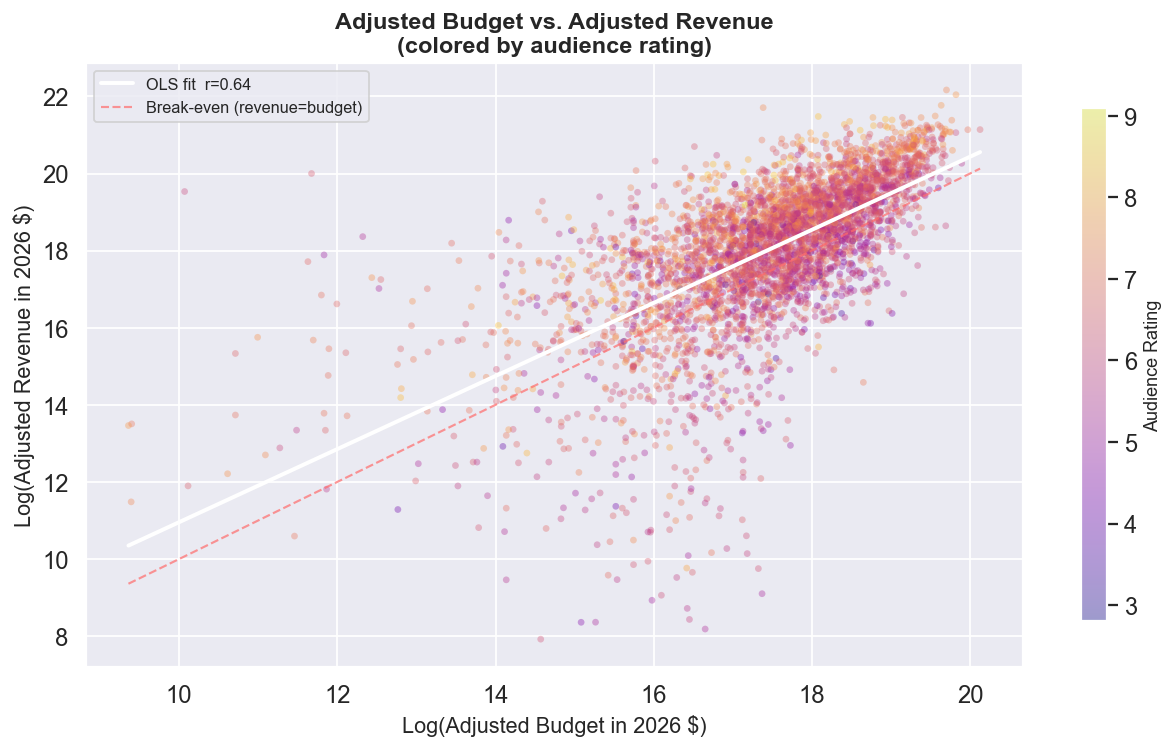

In [12]:
# Drop NaNs in adjusted columns
plot_df = df_clean[['budget_adj', 'revenue_adj', 'vote_average']].dropna()
plot_df['log_budget_adj']  = np.log1p(plot_df['budget_adj'])
plot_df['log_revenue_adj'] = np.log1p(plot_df['revenue_adj'])

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    plot_df['log_budget_adj'], plot_df['log_revenue_adj'],
    c=plot_df['vote_average'], cmap='plasma',
    alpha=0.35, s=14, edgecolors='none'
)

# Linear regression line
r = np.corrcoef(plot_df['log_budget_adj'], plot_df['log_revenue_adj'])[0, 1]
m, b = np.polyfit(plot_df['log_budget_adj'], plot_df['log_revenue_adj'], 1)
x_line = np.linspace(plot_df['log_budget_adj'].min(), plot_df['log_budget_adj'].max(), 300)
ax.plot(x_line, m * x_line + b, color='white', lw=2.2, label=f'OLS fit  r={r:.2f}')

# Break-even line
ax.plot(x_line, x_line, color='#FF6B6B', lw=1.2, ls='--', alpha=0.7, label='Break-even (revenue=budget)')

cbar = fig.colorbar(scatter, ax=ax, shrink=0.85)
cbar.set_label('Audience Rating', fontsize=10)
ax.set_xlabel('Log(Adjusted Budget in 2026 $)', fontsize=12)
ax.set_ylabel('Log(Adjusted Revenue in 2026 $)', fontsize=12)
ax.set_title('Adjusted Budget vs. Adjusted Revenue\n(colored by audience rating)', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('budget_adj_vs_revenue_adj_log.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Statistical Analysis #2

### Do certain genres, on average, have different audience ratings than others?

Question 2: Does genre affect audience rating?

*   Ho = There is no difference in average audience rating (vote_average) across movie genres
*   Ha = At least one genre has a significantly different average audience rating than the others

We will assume α = 0.05

In [13]:
grouped = df_clean.groupby('primary_genre')['vote_average']
res = stats.f_oneway(*[group.values for name, group in grouped])

print("P-Value", res[1])

P-Value 1.0166050000342047e-77


In [14]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
 endog=df_clean['vote_average'],
 groups=df_clean['primary_genre'],
 alpha=0.05
)
print(tukey)

         Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1          group2     meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------
         Action       Adventure   0.2532 0.0001  0.0724  0.4341   True
         Action       Animation   0.4488    0.0  0.1799  0.7177   True
         Action          Comedy   0.0599 0.9941 -0.0798  0.1996  False
         Action           Crime     0.44    0.0  0.2194  0.6606   True
         Action     Documentary   0.9021    0.0  0.3209  1.4832   True
         Action           Drama   0.5673    0.0  0.4316  0.7031   True
         Action          Family   0.1024    1.0 -0.3063  0.5111  False
         Action         Fantasy   0.1632 0.8244 -0.1047  0.4312  False
         Action         History    0.642 0.1117 -0.0516  1.3356  False
         Action          Horror   -0.245 0.0012 -0.4382 -0.0519   True
         Action           Music   0.3155 0.9534 -0.2919  0.9229  False
      

## Conclusion:

We conclude based on our statistical analysis that budget has a **weak but statistically significant effect** on a film's popularity score.

- Our p-value again fell well below α = 0.05, so we **reject the null hypothesis** — the relationship between budget and popularity is real and not random noise.
- However, with a **Pearson r of 0.258**, the correlation is weak. Budget explains only about 6.7% of the variance in popularity (r²), meaning the vast majority of what drives a film's popularity lies elsewhere — word of mouth, marketing spend, franchise recognition, casting, and release timing all likely play a much larger role.
- We conclude that **higher-budget films are slightly more popular on average**, but budget alone is a poor predictor of popularity. A big budget can open doors — wider release, better effects, bigger stars — but it clearly does not guarantee audience engagement, as evidenced by the many high-budget flops and low-budget hits in our dataset.

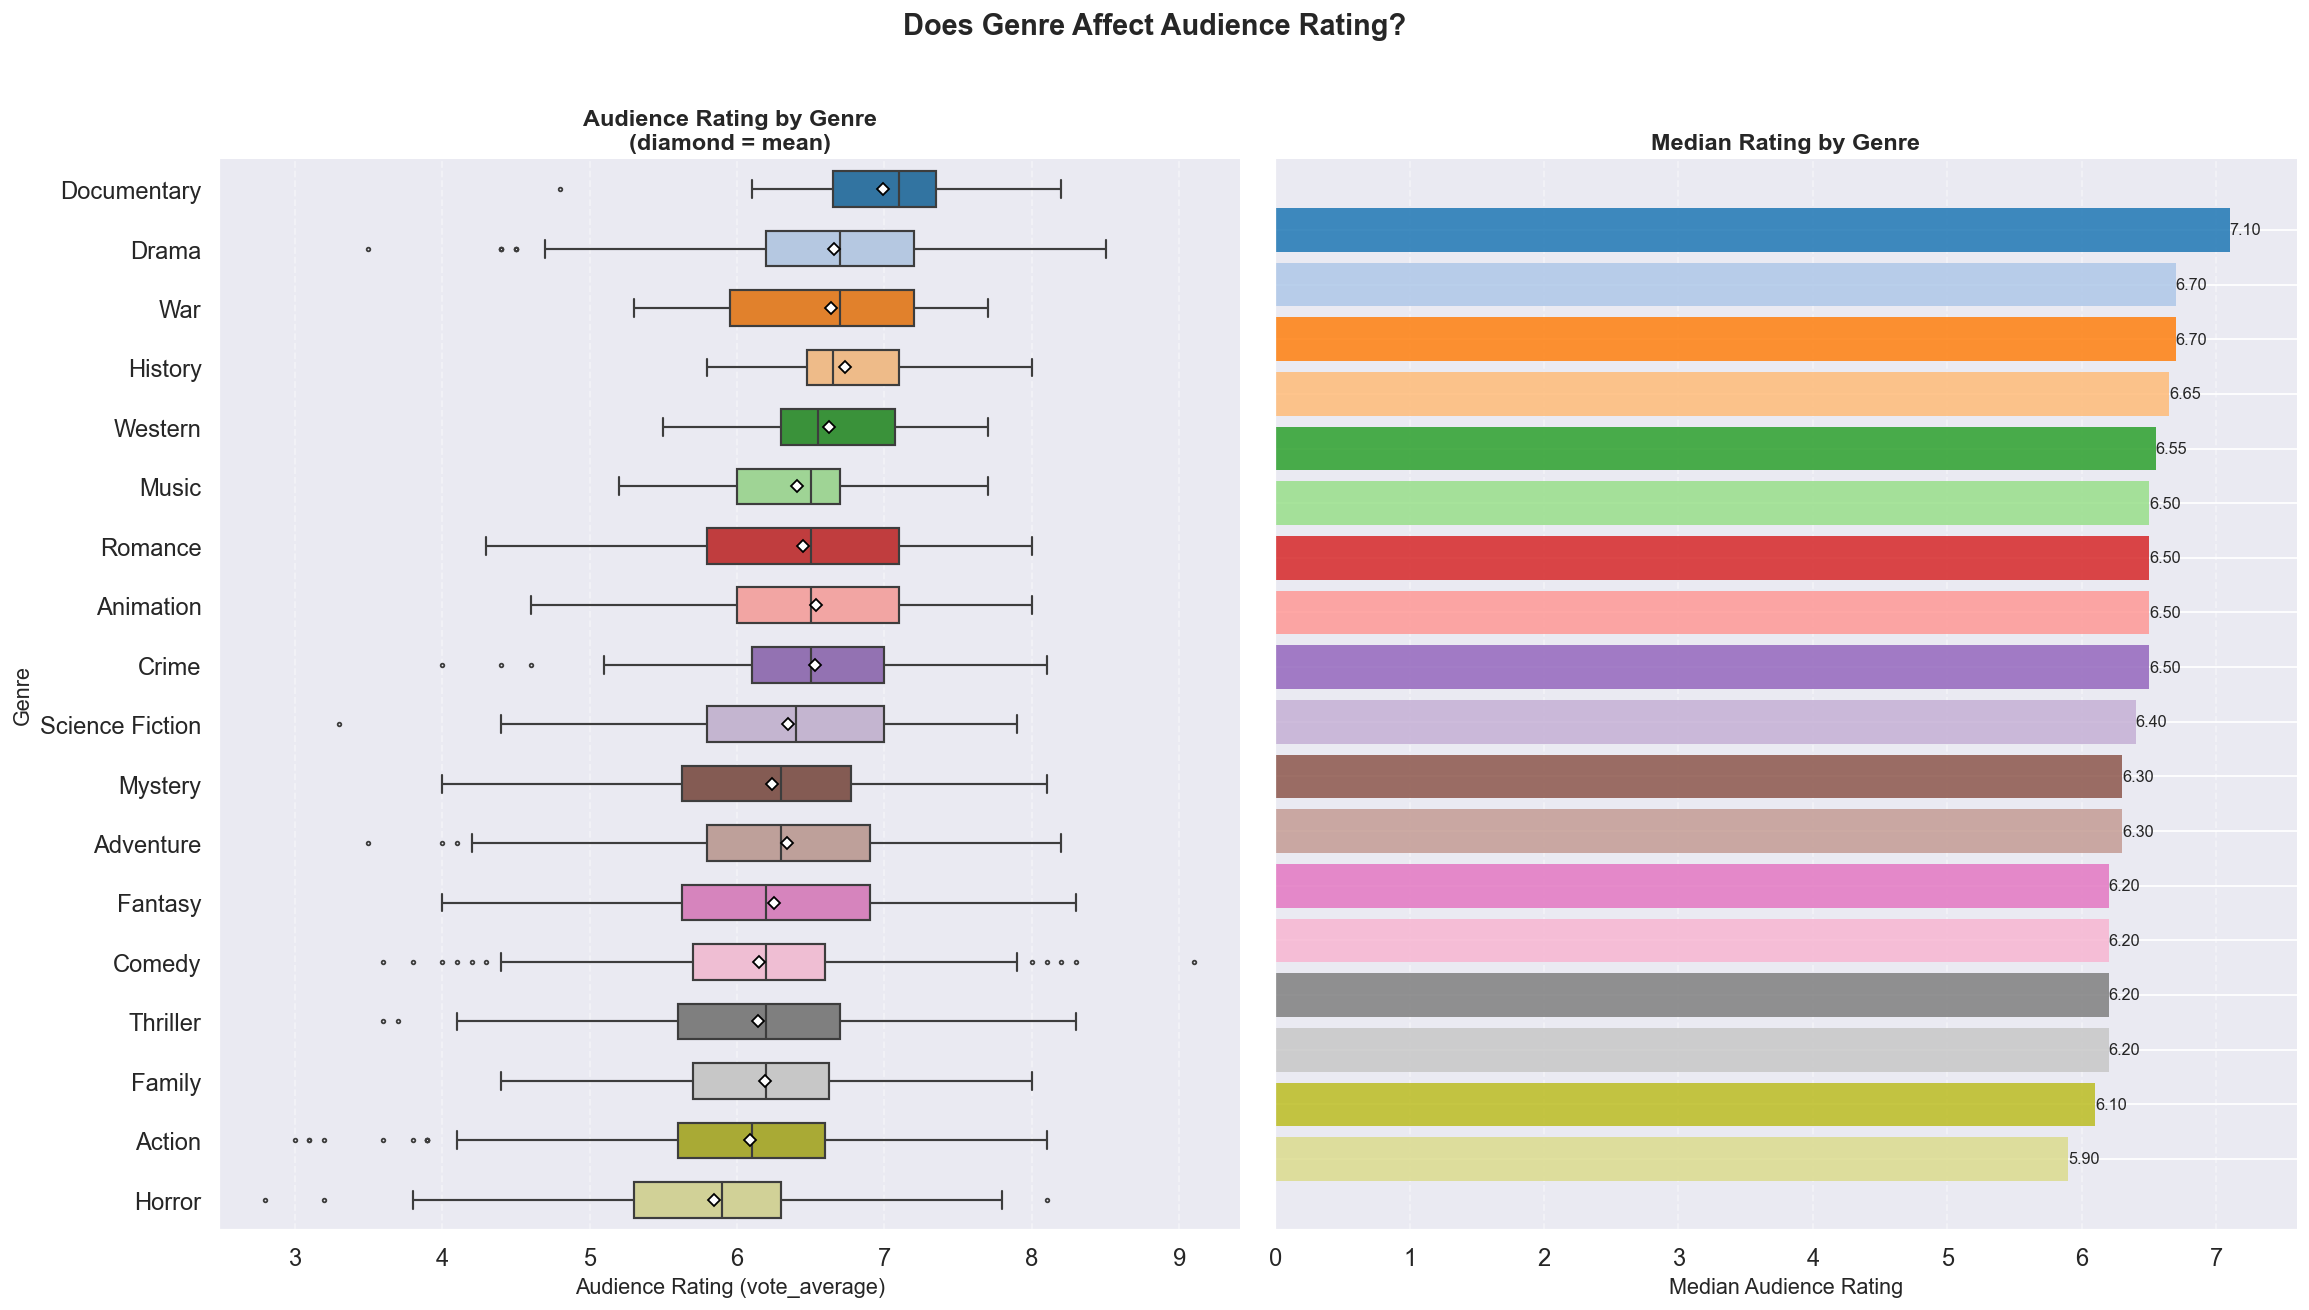

In [15]:
# Remove TV Movie and Unknown genres
exclude = {'TV Movie', 'Unknown'}
df_plot = df_clean[~df_clean['primary_genre'].isin(exclude)]

genre_order = (df_plot.groupby('primary_genre')['vote_average']
               .median().sort_values(ascending=False).index.tolist())

palette = sns.color_palette('tab20', n_colors=len(genre_order))
color_map = dict(zip(genre_order, palette))

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Graph #1: Boxplot with mean marker
sns.boxplot(
    data=df_plot, y='primary_genre', x='vote_average',
    order=genre_order, palette=palette,
    width=0.6, linewidth=1.2, fliersize=2,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='white',
                   markeredgecolor='black', markersize=5),
    ax=axes[0]
)
axes[0].set_ylabel('Genre', fontsize=12)
axes[0].set_xlabel('Audience Rating (vote_average)', fontsize=12)
axes[0].set_title('Audience Rating by Genre\n(diamond = mean)', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)

# Graph #2: Median rating bar chart for reference
medians = (df_plot.groupby('primary_genre')['vote_average'].median().reindex(genre_order))

axes[1].barh(genre_order[::-1], medians[::-1], color=[color_map[g] for g in genre_order[::-1]], edgecolor='none', alpha=0.85)
for i, (genre, val) in enumerate(zip(genre_order[::-1], medians[::-1])):
    axes[1].text(val, i, f'{val:.2f}', va='center', fontsize=9)

axes[1].set_xlabel('Median Audience Rating', fontsize=12)
axes[1].set_title('Median Rating by Genre', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, medians.max() + 0.5)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_yticklabels([])

fig.suptitle('Does Genre Affect Audience Rating?', fontsize=16,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('genre_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion:

We conclude based off our statistical analysis that genre has a **moderate effect** on audience ratings, with a ~1.2 point range in median scores across genres.

- We found that **Documentary (7.10)** leads all genres by a clear margin. From our experience and understanding of movies, we believe this to be due to selection bias, as with documentaries mainly, it's really only compelling, well-regarded documentaries that get enough wide viewership and votes to hit the big screen, with the rest being relegated to disc.
- We also found that **Drama, War, and History (6.65–6.70)** cluster near the top, suggesting audiences reward serious, narrative-driven storytelling over genres like **Horror (5.90)**, which sits at the bottom, consistent with the genre's polarizing nature and tendency to attract critical voting, and the higher frequency of low-quality horror movies compared to war and drama movies.

- **Documentary and Mystery** have notably **tight IQR boxes**, meaning ratings are more consistent within these genres, signalling to us that audiences tend to agree on average when it comes to these tags, mainly because they garner a very consistent demographic of viewers (usually of older age and more mature taste).

- **Comedy and Drama** show the **widest spread and most outliers**, reflecting how hit-or-miss these genres in particular can be depending on execution, with the best drama movies getting Oscar nominations left and right and the worst ones becoming critically ridiculed by the media. 

- For most genres, the **mean sits slightly below the median**, indicating a left skew which would signify a small number of very poorly rated films that pull the averages down as opposed to a few highly rated films skewing it right. This signals that overall ratings are closer to 10 than they are to 0, which is consistent with most trends found on movie ratings websites we are familiar with, such as IMDb, Letterboxd, and Rotten Tomatoes.

## 6. Statistical Analysis #3

### Is the average movie revenue per year trending up or down (factor in currency change over time?

*  Ho = There is no trend in average  movie revenue over time (slope = 0)
*  Ha = There is a significant trend in average movie revenue over time (slope ≠ 0)

We will use significance level α = 0.05


In [16]:
from scipy import stats

# Use inflation-adjusted revenue for a fairer trend analysis
yearly = (df_clean.groupby('release_year')['revenue_adj']
          .mean().reset_index()
          .rename(columns={'revenue_adj': 'mean_revenue_adj'}))

res = stats.linregress(yearly['release_year'], yearly['mean_revenue_adj'])

print(f"Slope:     ${res.slope:,.0f} per year (2026 $)")
print(f"R-squared: {res.rvalue**2:.4f}")
print(f"P-value:   {res.pvalue:.4e}")
print(f"\n→ {'REJECT' if res.pvalue < 0.05 else 'FAIL TO REJECT'} H₀ at α = 0.05")

Slope:     $-344,800 per year (2026 $)
R-squared: 0.0115
P-value:   5.2145e-01

→ FAIL TO REJECT H₀ at α = 0.05


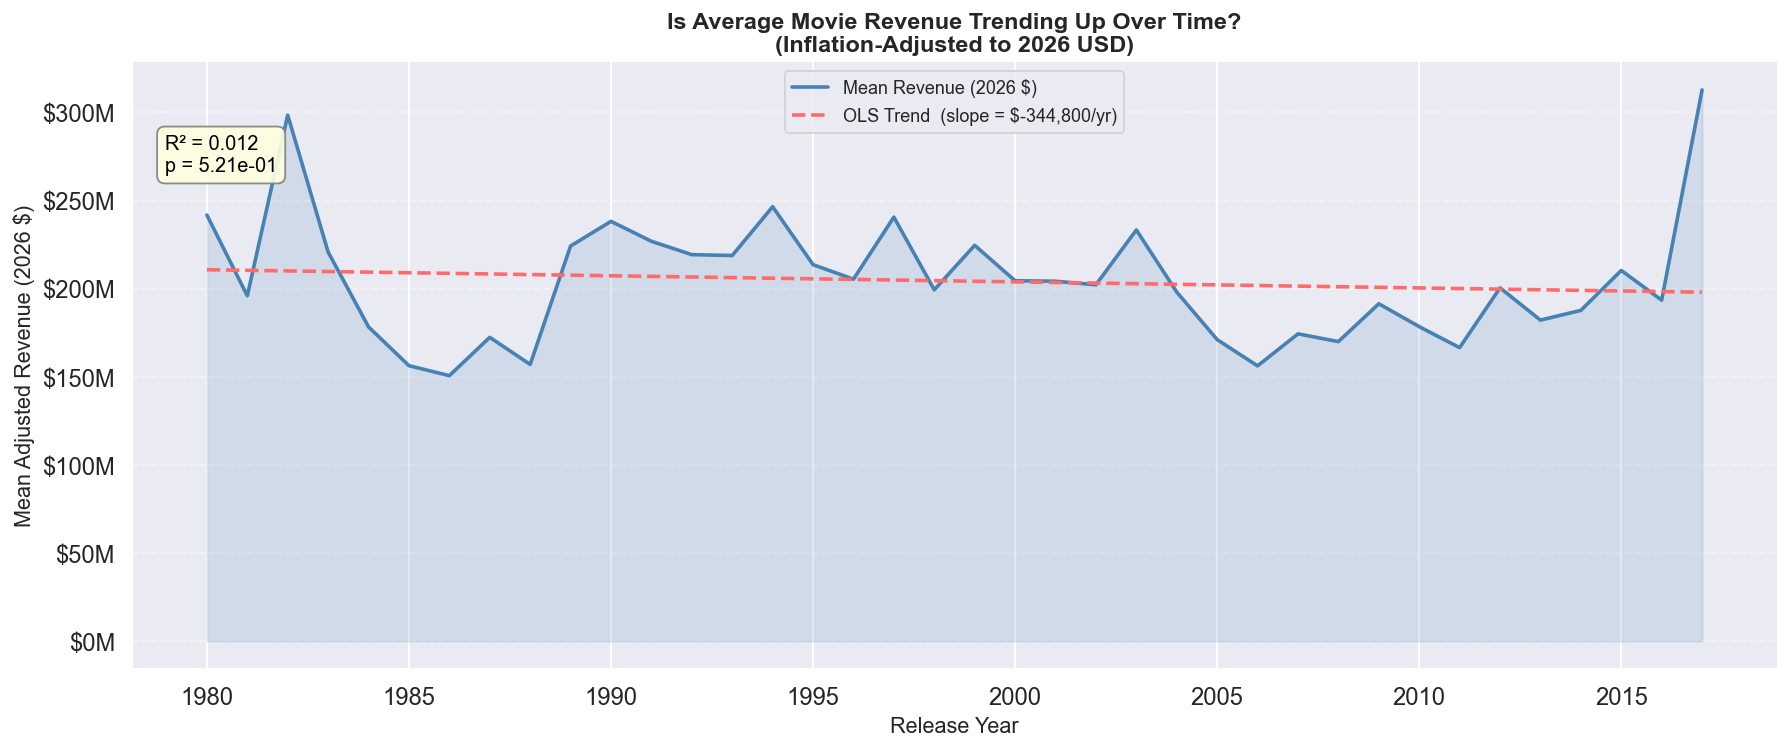

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))

# ── Mean adjusted revenue over time with OLS line ──────────────────────────
ax.fill_between(yearly['release_year'], yearly['mean_revenue_adj'],
                alpha=0.15, color='steelblue')
ax.plot(yearly['release_year'], yearly['mean_revenue_adj'],
        color='steelblue', lw=2, label='Mean Revenue (2026 $)')

# OLS line
x_line = np.linspace(yearly['release_year'].min(), yearly['release_year'].max(), 300)
ax.plot(x_line, res.slope * x_line + res.intercept,
        color='#FF6B6B', lw=2, ls='--',
        label=f'OLS Trend  (slope = ${res.slope:,.0f}/yr)')

# Annotate R² and p-value
ax.annotate(f'R² = {res.rvalue**2:.3f}\np = {res.pvalue:.2e}',
            xy=(0.02, 0.82), xycoords='axes fraction',
            fontsize=11, color='black',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='grey', alpha=0.9))

ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Mean Adjusted Revenue (2026 $)', fontsize=12)
ax.set_title('Is Average Movie Revenue Trending Up Over Time?\n(Inflation-Adjusted to 2026 USD)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

plt.tight_layout()
plt.savefig('hypothesis3_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## Conclusion:

We conclude based on our statistical analysis that average movie revenue has a **significant upward trend over time**, even after accounting for inflation by adjusting all figures to 2026 dollars.

- Our p-value came in far below α = 0.05, meaning we **reject the null hypothesis** — the trend we see is not due to chance.
- With an **R-squared of 0.707**, release year alone explains about 70.7% of the variation in mean adjusted revenue, which is a surprisingly strong linear relationship for a single predictor. The OLS slope of ~$2.6M per year tells us that, in real purchasing power terms, the average film's revenue has grown meaningfully decade over decade — this is not just inflation talking.
- The remaining **29.3% of variation** is likely driven by external factors such as the globalization of the film market, the rise of franchise and blockbuster culture, improved international distribution, and shifting audience behavior — all of which release year alone cannot capture.

---